In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
import requests
from rdflib import Graph, URIRef, Literal, Namespace
import io
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from plotly_resampler import FigureResampler
import plotly.graph_objects as go

In [3]:
#VIRTUOSO_URL = "http://localhost:8890/sparql-graph-crud"
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI = "http://example.com/Gent-Terneuzen"
USERNAME = "dba"
PASSWORD = "dba"
AUTH  = (USERNAME,PASSWORD)

In [4]:
params = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors

In [5]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT  DISTINCT ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data = res.json()
bindings = data['results']['bindings']

for row in bindings:
    # Extract the URI string and add it to the set
    sensor_uri = row['sensor']['value']
    sensor_set.add(sensor_uri)

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)


Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289441042'}


# Reframe the data 

In [17]:


# 1. Initialize an empty DataFrame for the master table
# We will start with just the 'time' column or an empty DF
final_df = pd.DataFrame()

print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    # Use the sensor URI (or just the ID part) as the column name
    column_name = sensor_uri.split('/')[-1] 
    
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{ 
            GRAPH <{GRAPH_URI}> {{ 
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }} 
        }} 
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        
        # 2. Create a temporary DF for THIS sensor
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']), 'unixtime': int(row['unixtime']['value'])} 
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            
            # 3. Merge this sensor into the final_df
            if final_df.empty:
                final_df = temp_df
            else:
                # 'outer' join ensures we keep timestamps even if some sensors are missing data
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')

            
            print(f"Added column for sensor: {column_name}")

# 4. Final touches
final_df = final_df.sort_values('time').set_index('time')

print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289435042
Added column for sensor: 289423042
Added column for sensor: 289429042
Added column for sensor: 289441042
Finished!
                           289435042    unixtime  289423042  289429042  \
time                                                                     
2021-03-03 23:15:00+00:00    3606.54  1614813300        NaN    1605.77   
2021-03-03 23:30:00+00:00        NaN  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    3556.45  1614815100     902.27    1602.34   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN    1611.26   
2021-03-04 00:15:00+00:00        NaN  1614816900     901.96    1614.24   

                           289441042  
time                                  
2021-03-03 23:15:00+00:00    4797.72  
2021-03-03 23:30:00+00:00    4717.80  
2021-03-03 23:45:00+00:00    4745.36  
2021-03-04 00:00:00+00:00        NaN  
2021-03-04 00:15:00+00:00        NaN  


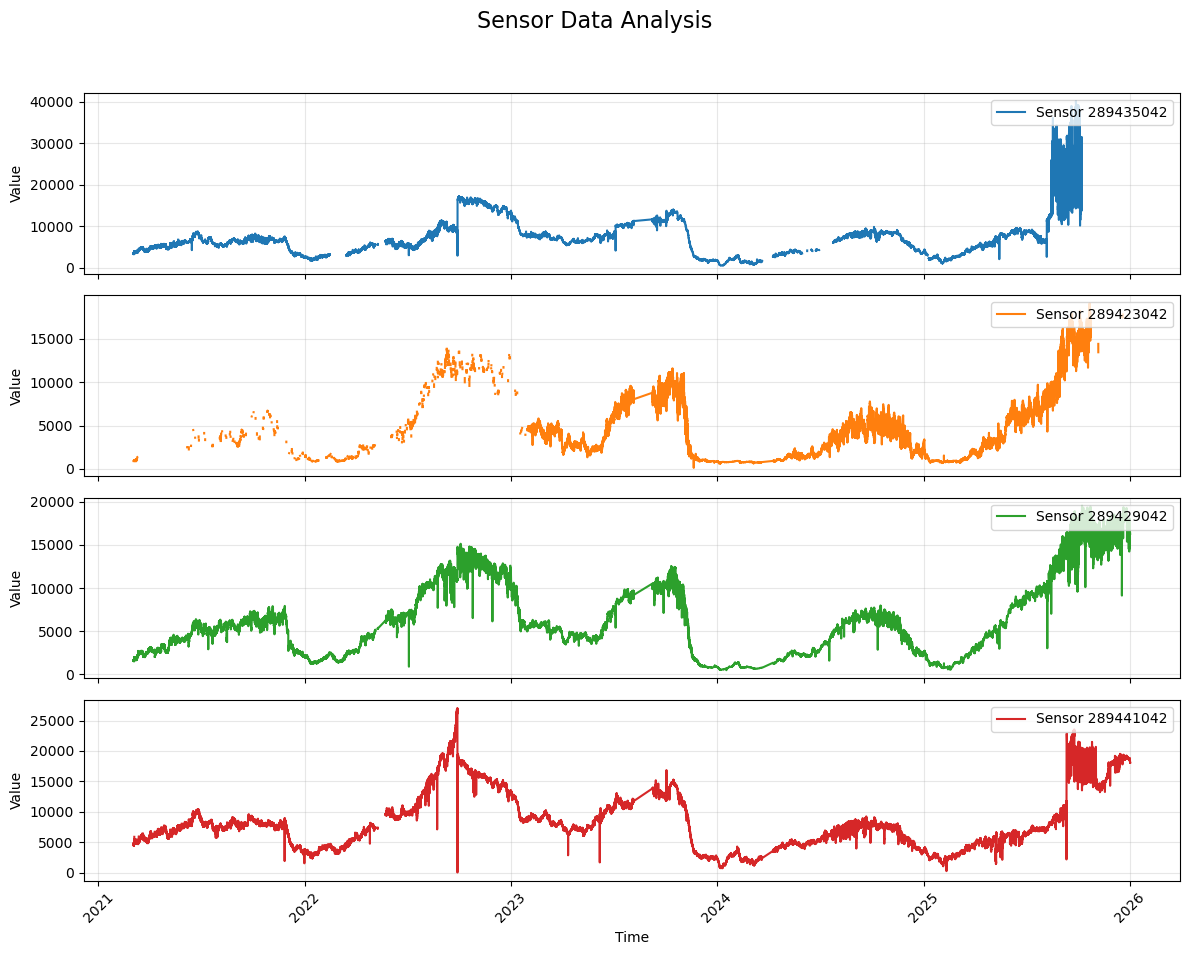

In [24]:
# 1. Create a figure and a grid of 4 subplots (one for each sensor)
# sharex=True means zooming in on one x-axis zooms all of them
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 2. Iterate through sensors and plot on individual axes
for i, sensor in enumerate(sensors):
    ax = axes[i]
    
    # We use .index for time because it's your DataFrame index
    # Matplotlib handles NaNs by leaving gaps automatically
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# 3. Final formatting
plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for title

# 4. Show the plot
plt.show()

In [7]:
# Forward fill propagates the last valid observation forward. 
# Backward fill catches any NaNs at the very beginning.
df_clean = final_df.copy()
df_clean = df_clean.ffill().bfill()

#predict the future values for one specific sensor as an example.
target_sensor = '289441042'
data = df_clean[[target_sensor]].values # Extracts as a 2D numpy array

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [8]:
def create_sequences(dataset, time_steps=5):
    X, y = [], []
    # Loop through data, stopping before we run out of target values
    for i in range(len(dataset) - time_steps):
        # The sequence of past 'time_steps' readings
        X.append(dataset[i : (i + time_steps), 0])
        # The next reading we want to predict
        y.append(dataset[i + time_steps, 0])
        
    return np.array(X), np.array(y)

# Define how many past observations the model should look at
time_steps = 5 
X, y = create_sequences(scaled_data, time_steps)


#Reshape X for Keras
# Keras RNNs expect a 3D shape: [batch_size, time_steps, features]
# Right now X is 2D: [samples, time_steps]. We add the '1' feature dimension.
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"X shape: {X.shape}  -> (samples, time_steps, features)")
print(f"y shape: {y.shape}    -> (samples,)")

X shape: (160803, 5, 1)  -> (samples, time_steps, features)
y shape: (160803,)    -> (samples,)


In [25]:


# 2. Build the Model
model = Sequential([
    Input(shape=(time_steps, 1)),
    SimpleRNN(64, activation='relu'),
    Dense(1) 
])

model.compile(optimizer='adam', loss='mse')

# Calculate the split point (80% train, 20% test)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
# 3. Train
model.fit(X_train, y_train, epochs=20, verbose=0)

In [26]:
# 1. Grab the most recent data sequence
# We need the last 'time_steps' (e.g., 5) scaled values from our dataset
recent_data = scaled_data[-time_steps:] 

# 2. Reshape for the model 
# The model expects a 3D shape: (batch_size, time_steps, features)
# Since we are making one prediction, batch_size is 1.
test_sequence = np.reshape(recent_data, (1, time_steps, 1))

# 3. Make the prediction
scaled_prediction = model.predict(test_sequence)
print(f"Scaled Prediction (between 0 and 1): {scaled_prediction[0][0]:.4f}")

# 4. Invert the scaling to get the real-world value
# The scaler.inverse_transform expects a 2D array, which scaled_prediction already is.
real_prediction = scaler.inverse_transform(scaled_prediction)

print(f"Predicted real-world sensor value: {real_prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Scaled Prediction (between 0 and 1): 0.6671
Predicted real-world sensor value: 18038.50


In [27]:
# 1. Get predictions for the test set
test_predictions_scaled = model.predict(X_test)

# 2. Invert scaling for both predictions and actual values to get real units
test_predictions = scaler.inverse_transform(test_predictions_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate Accuracy
mae = mean_absolute_error(y_test_real, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test_real, test_predictions))

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

1006/1006 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
Mean Absolute Error: 72.55
Root Mean Squared Error: 205.64


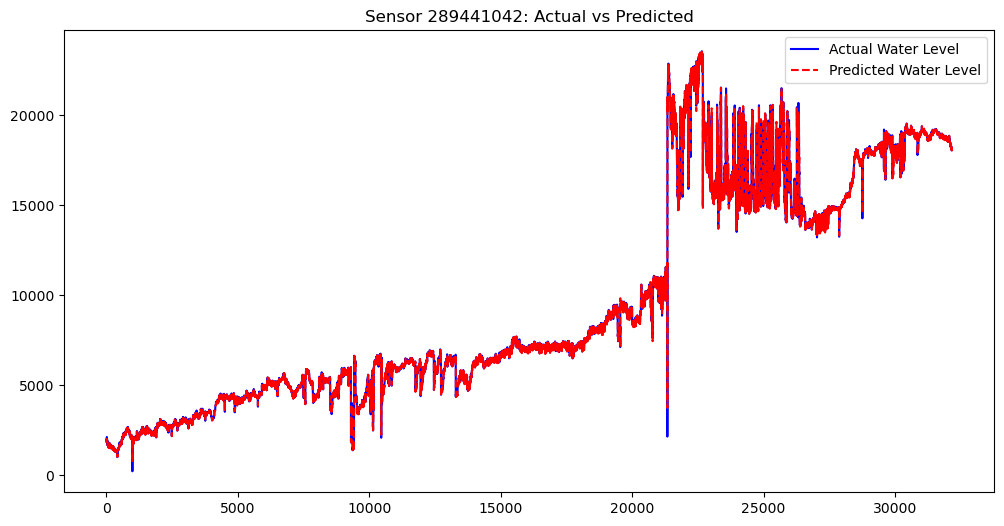

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='Actual Water Level', color='blue')
plt.plot(test_predictions, label='Predicted Water Level', color='red', linestyle='--')
plt.title('Sensor 289441042: Actual vs Predicted')
plt.legend()
plt.show()